# Visualizing Monthy Precipitation Anomalies at Moundville, AL

---

### Overview

Here we will use ERA5 data to visualize precipitation anomalies at Moundville, AL from 1979 to 2025. We will use data from Earth Data Hub and select the variable we are interested in plotting (precipitation anomaly). 


### Imports

In [10]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

#### Getting ERA5 data from Earth Data Hub 

In [6]:
ds= xr.open_dataset(
    "https://data.earthdatahub.destine.eu/more-era5/ecv-for-climate-change-1981-2010-anomaly-v0",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",)

In [7]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:     (valid_time: 562, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1979-01-01 ... 2025-10-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    r           (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
    siconc      (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-06T12:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [8]:
precip = ds['tp']

lat_pt = 33.0
lon_pt = -87.6
if lon_pt < 0:
    lon_pt = lon_pt + 360

### Plotting 

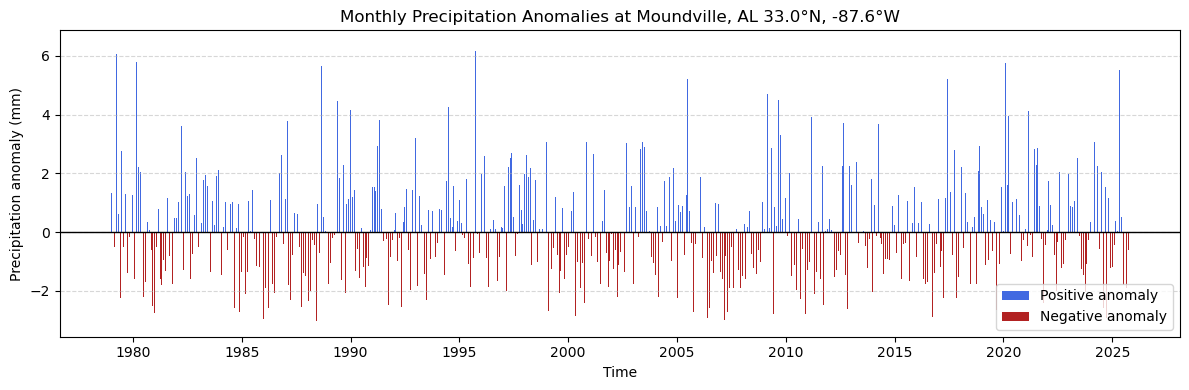

In [13]:
precip_point = precip.sel(latitude=lat_pt, longitude=lon_pt, method="nearest")
precip_series = precip_point.to_series()

# Convert to pandas Series and convert m → mm
precip_series = precip_point.to_series() * 1000  # now in mm

plt.figure(figsize=(12,4))

# Set the bar width, color, and labels
bar_width = np.timedelta64(15, 'D')

plt.bar(precip_series.index, precip_series.where(precip_series >= 0),
        width=bar_width, color='royalblue', label='Positive anomaly')
plt.bar(precip_series.index, precip_series.where(precip_series < 0),
        width=bar_width, color='firebrick', label='Negative anomaly')

plt.axhline(0, color='k', lw=1)
plt.title(f"Monthly Precipitation Anomalies at Moundville, AL {lat_pt}°N, {lon_pt-360:.1f}°W")
plt.xlabel("Time")
plt.ylabel("Precipitation anomaly (mm)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Make x-axis show every 5 years
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---

### Summary

Now we can view the monthly precipitation anomalies to see how it has changed over time. We learned how to subset data for a location and specific variable, followed by how to plot the monthly anomalies in a bar chart format. 